# STG training results

Plots for `history_stg.csv`: losses, accuracy, regularization, average STG probabilities, active channel counts, and per-block channel zero probabilities.

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 7)


def find_history_file(file_name="history_stg.csv"):
    roots = [Path.cwd(), *Path.cwd().parents]
    candidates = []
    for root in roots:
        candidates.extend([
            root / file_name,
            root / "github" / file_name,
        ])

    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if candidate.exists():
            return candidate

    checked = "\n".join(str(path) for path in candidates)
    raise FileNotFoundError(f"Could not find {file_name}. Checked:\n{checked}")


history_path = find_history_file()
df = pd.read_csv(history_path)

print(f"Loaded: {history_path}")
print(f"Rows: {len(df)}, columns: {len(df.columns)}")
display(df.head())

Loaded: /Users/grigorii/MIPT/Матпрак/history_stg.csv
Rows: 250, columns: 756


,epoch,train_ce_loss,train_regularization_loss,train_loss,train_accuracy,train_backbone.layer1.0.stg_layer_avg_estim_prob,train_backbone.layer1.0.stg_layer_avg_real_prob,train_backbone.layer1.0.stg_layer_avg_zero_prob,train_backbone.layer1.0.stg_layer.channel_000_zero_prob,train_backbone.layer1.0.stg_layer.channel_001_zero_prob,...,valid_average_real_prob,valid_max_real_prob,valid_min_real_prob,valid_average_estim_prob,valid_max_estim_prob,valid_min_estim_prob,valid_min_estimm_prob,valid_average_zero_prob,valid_max_zero_prob,valid_min_zero_prob
0,1,1.991472,0.976555,3.436256,0.270758,0.976560,1.0,0.023440,0.024635,0.025312,...,1.0,1.0,1.0,0.976250,0.976754,0.975149,0.975149,0.023750,0.024851,0.023246
1,2,1.625117,0.976110,3.069243,0.391752,0.977043,1.0,0.022957,0.023842,0.024124,...,1.0,1.0,1.0,0.975985,0.977427,0.973952,0.973952,0.024015,0.026048,0.022573
2,3,1.458977,0.975942,2.902853,0.461789,0.977931,1.0,0.022069,0.022520,0.022298,...,1.0,1.0,1.0,0.975902,0.978384,0.972724,0.972724,0.024098,0.027276,0.021616
3,4,1.341984,0.975881,2.785770,0.508489,0.978813,1.0,0.021187,0.021323,0.020906,...,1.0,1.0,1.0,0.975878,0.979326,0.971212,0.971212,0.024122,0.028788,0.020674
4,5,1.234158,0.975923,2.678007,0.553335,0.979788,1.0,0.020212,0.020423,0.019658,...,1.0,1.0,1.0,0.975966,0.980157,0.970162,0.970162,0.024034,0.029838,0.019843


In [9]:
summary_columns = [
    "epoch",
    "train_loss",
    "valid_loss",
    "train_ce_loss",
    "valid_ce_loss",
    "train_regularization_loss",
    "valid_regularization_loss",
    "train_accuracy",
    "valid_accuracy",
    "train_average_estim_prob",
    "valid_average_estim_prob",
    "train_average_zero_prob",
    "valid_average_zero_prob",
]
summary_columns = [column for column in summary_columns if column in df.columns]

best_valid_idx = df["valid_accuracy"].idxmax()
best_valid = df.loc[best_valid_idx, summary_columns]
last_epoch = df.loc[df.index[-1], summary_columns]

summary = pd.DataFrame({
    "best_valid_accuracy": best_valid,
    "last_epoch": last_epoch,
})
display(summary)

,best_valid_accuracy,last_epoch
epoch,103.000000,250.000000
train_loss,1.101451,1.067327
valid_loss,1.423761,1.471353
train_ce_loss,0.092938,0.062723
valid_ce_loss,0.415299,0.466753
train_regularization_loss,0.681672,0.679030
valid_regularization_loss,0.681638,0.679027
train_accuracy,0.969076,0.980068
valid_accuracy,0.886185,0.884329
train_average_estim_prob,0.681672,0.679030


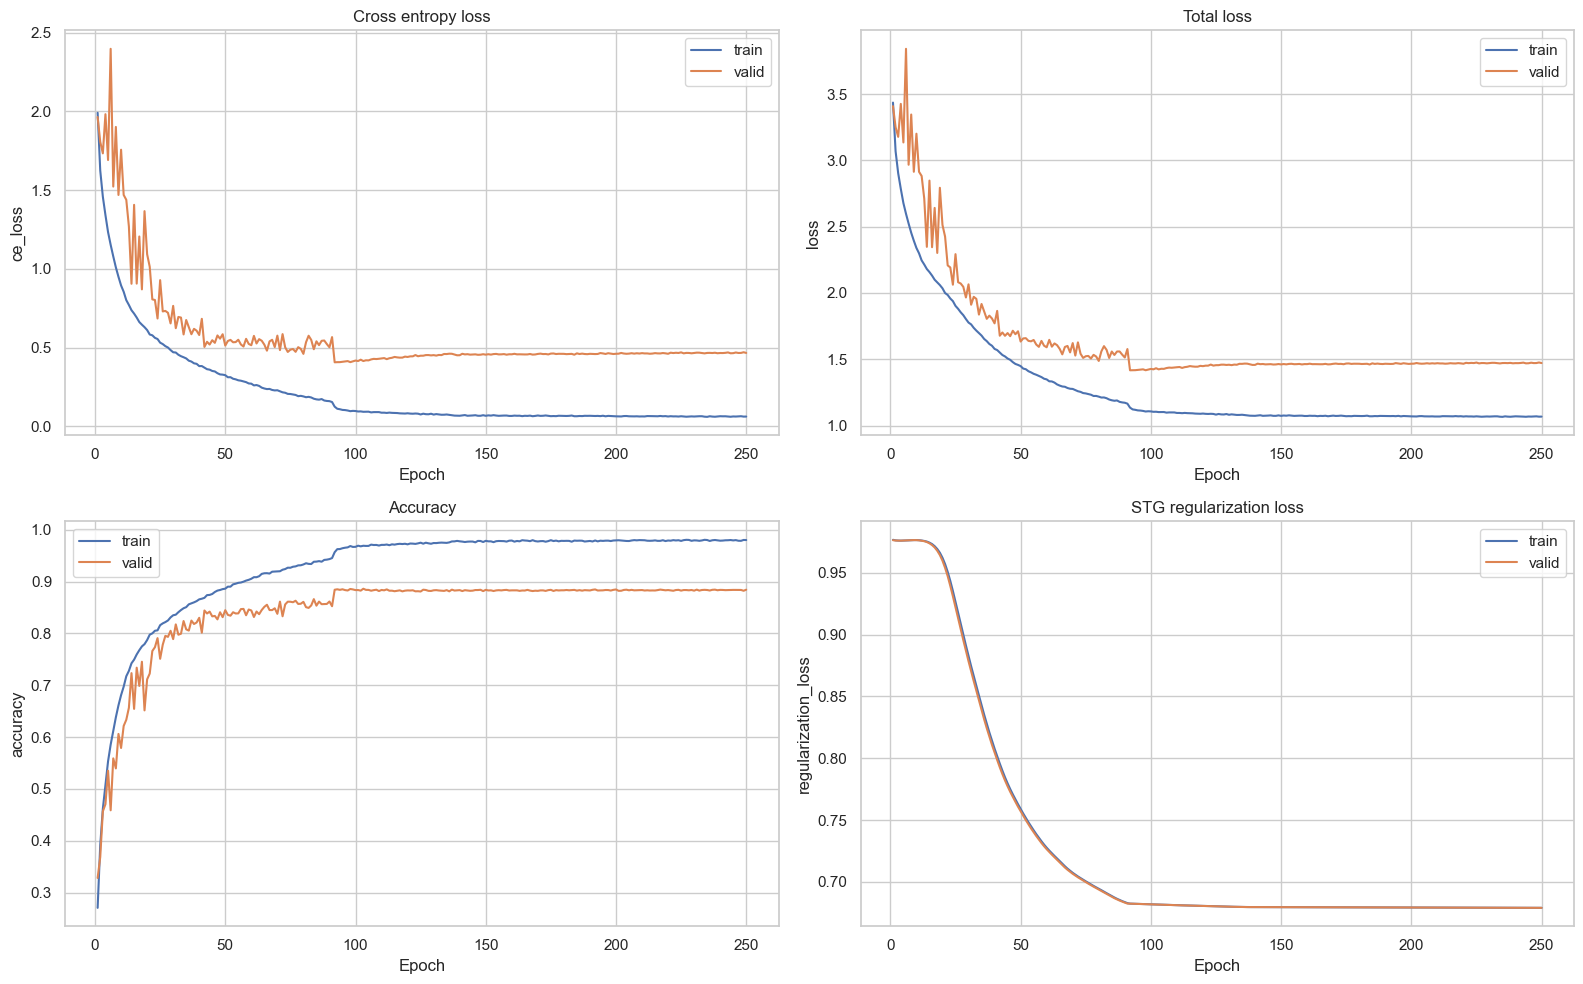

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

pairs = [
    ("ce_loss", "Cross entropy loss"),
    ("loss", "Total loss"),
    ("accuracy", "Accuracy"),
    ("regularization_loss", "STG regularization loss"),
]

for ax, (metric, title) in zip(axes.ravel(), pairs):
    for stage in ["train", "valid"]:
        column = f"{stage}_{metric}"
        if column in df.columns:
            sns.lineplot(data=df, x="epoch", y=column, label=stage, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric)
    ax.legend()

plt.tight_layout()
plt.show()

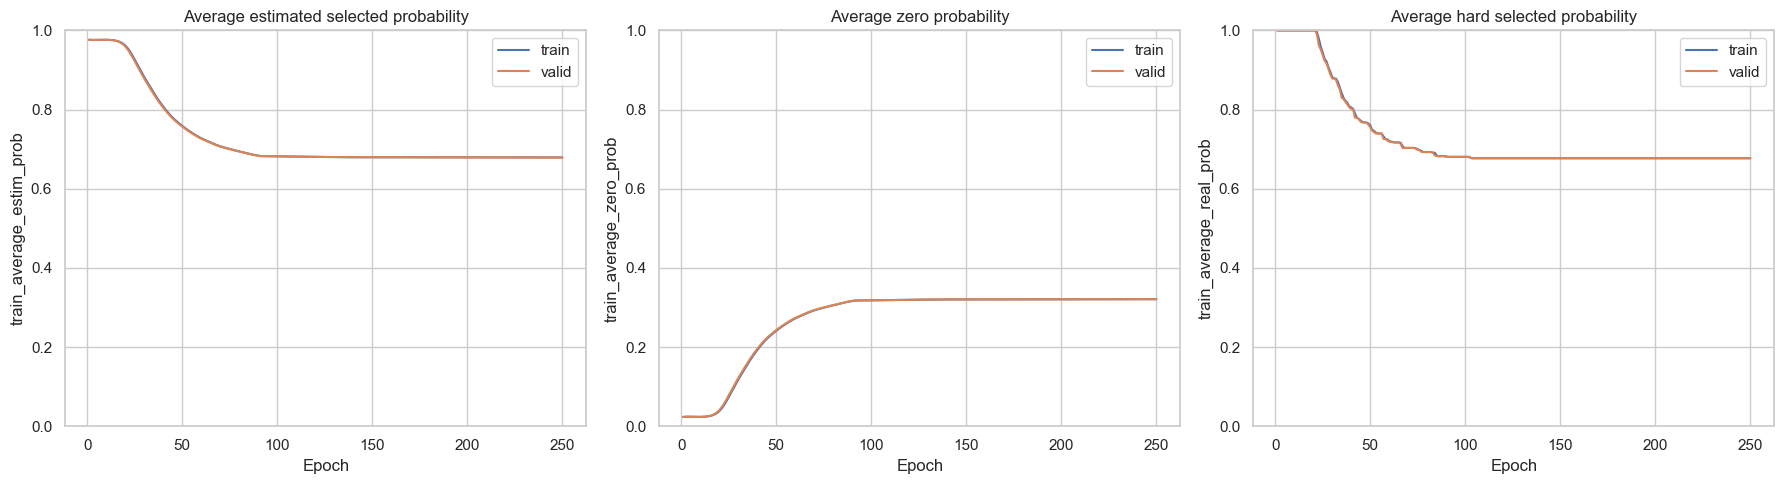

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

prob_metrics = [
    ("average_estim_prob", "Average estimated selected probability"),
    ("average_zero_prob", "Average zero probability"),
    ("average_real_prob", "Average hard selected probability"),
]

for ax, (metric, title) in zip(axes, prob_metrics):
    for stage in ["train", "valid"]:
        column = f"{stage}_{metric}"
        if column in df.columns:
            sns.lineplot(data=df, x="epoch", y=column, label=stage, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylim(0, 1)
    ax.legend()

plt.tight_layout()
plt.show()

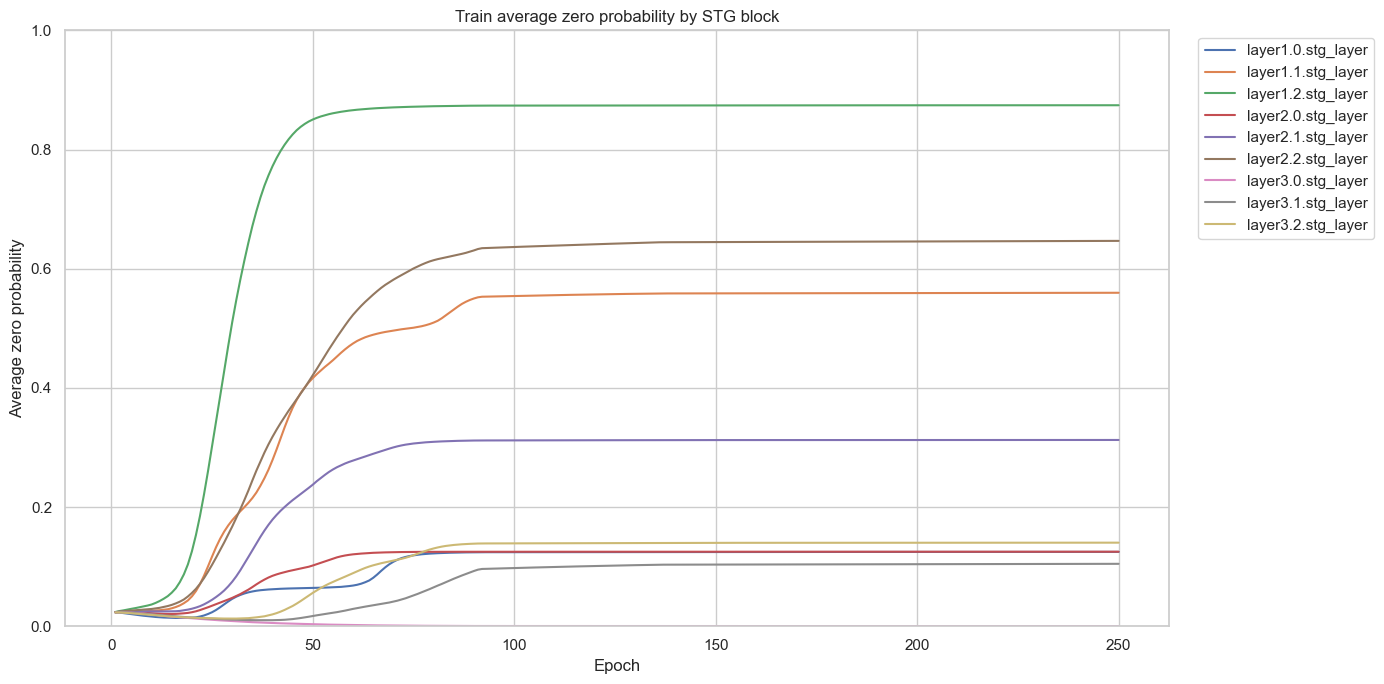

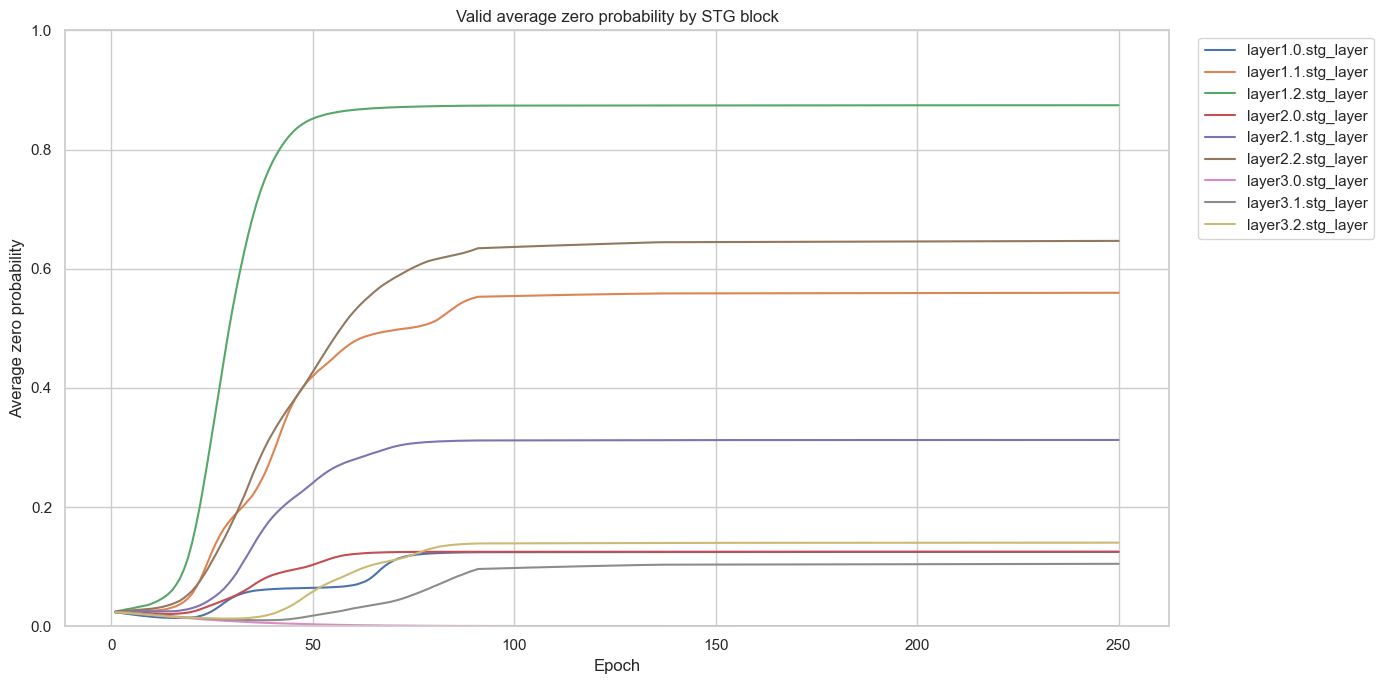

In [12]:
def block_name_from_avg_column(column, stage="valid"):
    prefix = f"{stage}_backbone."
    suffix = "_avg_zero_prob"
    return column.removeprefix(prefix).removesuffix(suffix)


for stage in ["train", "valid"]:
    avg_zero_columns = [
        column for column in df.columns
        if column.startswith(f"{stage}_backbone.") and column.endswith("_avg_zero_prob")
    ]
    if not avg_zero_columns:
        continue

    long_df = df[["epoch", *avg_zero_columns]].melt(
        id_vars="epoch",
        var_name="block",
        value_name="avg_zero_prob",
    )
    long_df["block"] = long_df["block"].map(lambda column: block_name_from_avg_column(column, stage=stage))

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=long_df, x="epoch", y="avg_zero_prob", hue="block")
    plt.title(f"{stage.capitalize()} average zero probability by STG block")
    plt.xlabel("Epoch")
    plt.ylabel("Average zero probability")
    plt.ylim(0, 1)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

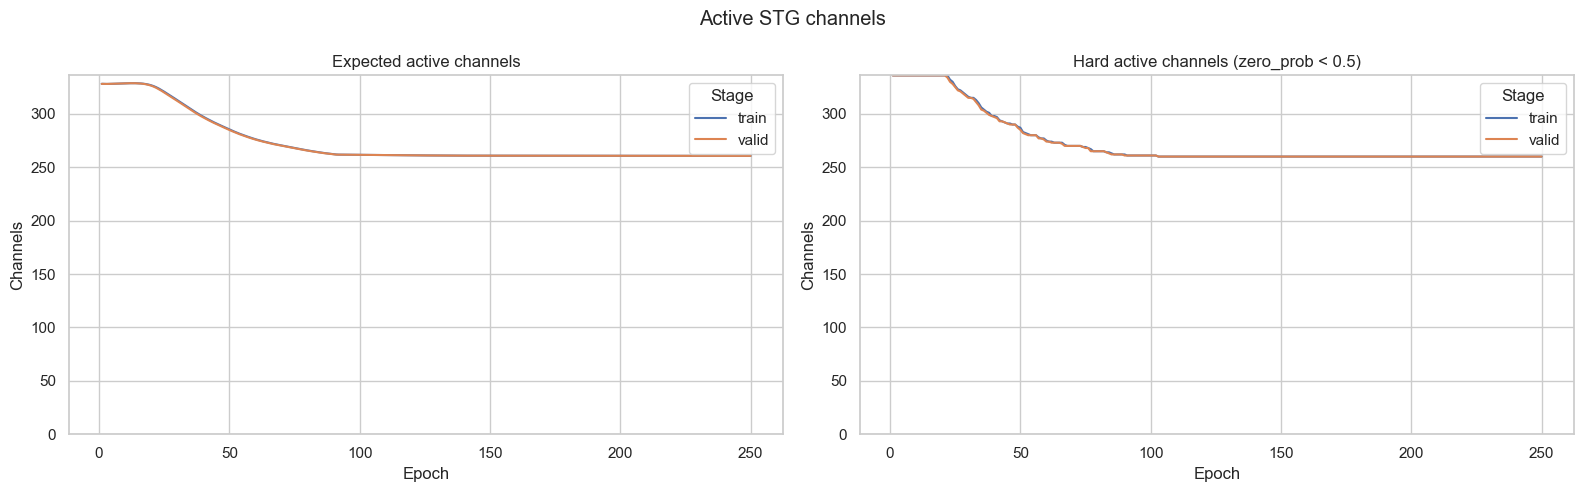

In [15]:
def parse_channel_zero_column(column, stage="valid"):
    prefix = f"{stage}_backbone."
    block, channel = column.removeprefix(prefix).split(".channel_")
    channel = int(channel.removesuffix("_zero_prob"))
    return block, channel


active_rows = []
for stage in ["train", "valid"]:
    channel_zero_columns = [
        column for column in df.columns
        if column.startswith(f"{stage}_backbone.") and ".channel_" in column and column.endswith("_zero_prob")
    ]

    block_to_columns = {}
    for column in channel_zero_columns:
        block, _ = parse_channel_zero_column(column, stage=stage)
        block_to_columns.setdefault(block, []).append(column)

    for _, row in df[["epoch", *channel_zero_columns]].iterrows():
        for block, columns in block_to_columns.items():
            zero_probs = row[columns].astype(float).to_numpy()
            active_rows.append({
                "epoch": row["epoch"],
                "stage": stage,
                "block": block,
                "expected_active_channels": float((1.0 - zero_probs).sum()),
                "hard_active_channels": int((zero_probs < 0.5).sum()),
                "total_channels": int(len(columns)),
            })

active_channels = pd.DataFrame(active_rows)
total_active_channels = (
    active_channels
    .groupby(["epoch", "stage"], as_index=False)
    .agg(
        expected_active_channels=("expected_active_channels", "sum"),
        hard_active_channels=("hard_active_channels", "sum"),
        total_channels=("total_channels", "sum"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

sns.lineplot(
    data=total_active_channels,
    x="epoch",
    y="expected_active_channels",
    hue="stage",
    ax=axes[0],
)
axes[0].set_title("Expected active channels")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Channels")
axes[0].set_ylim(0, total_active_channels["total_channels"].max())
axes[0].legend(title="Stage")

sns.lineplot(
    data=total_active_channels,
    x="epoch",
    y="hard_active_channels",
    hue="stage",
    ax=axes[1],
)
axes[1].set_title("Hard active channels (zero_prob < 0.5)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Channels")
axes[1].set_ylim(0, total_active_channels["total_channels"].max())
axes[1].legend(title="Stage")

plt.suptitle("Active STG channels")
plt.tight_layout()
plt.show()

In [13]:
def parse_channel_zero_column(column, stage="valid"):
    prefix = f"{stage}_backbone."
    block, channel = column.removeprefix(prefix).split(".channel_")
    channel = int(channel.removesuffix("_zero_prob"))
    return block, channel


stage = "valid"
channel_zero_columns = [
    column for column in df.columns
    if column.startswith(f"{stage}_backbone.") and ".channel_" in column and column.endswith("_zero_prob")
]

final = df.iloc[-1]
rows = []
for column in channel_zero_columns:
    block, channel = parse_channel_zero_column(column, stage=stage)
    rows.append({
        "block": block,
        "channel": channel,
        "zero_prob": final[column],
    })

final_zero = pd.DataFrame(rows)
display(final_zero.sort_values("zero_prob", ascending=False).head(20))

,block,channel,zero_prob
22,layer1.1.stg_layer,6,0.999577
34,layer1.2.stg_layer,2,0.999568
41,layer1.2.stg_layer,9,0.999512
23,layer1.1.stg_layer,7,0.999499
38,layer1.2.stg_layer,6,0.999497
141,layer2.2.stg_layer,29,0.999496
37,layer1.2.stg_layer,5,0.999492
46,layer1.2.stg_layer,14,0.999488
17,layer1.1.stg_layer,1,0.999480
44,layer1.2.stg_layer,12,0.999476


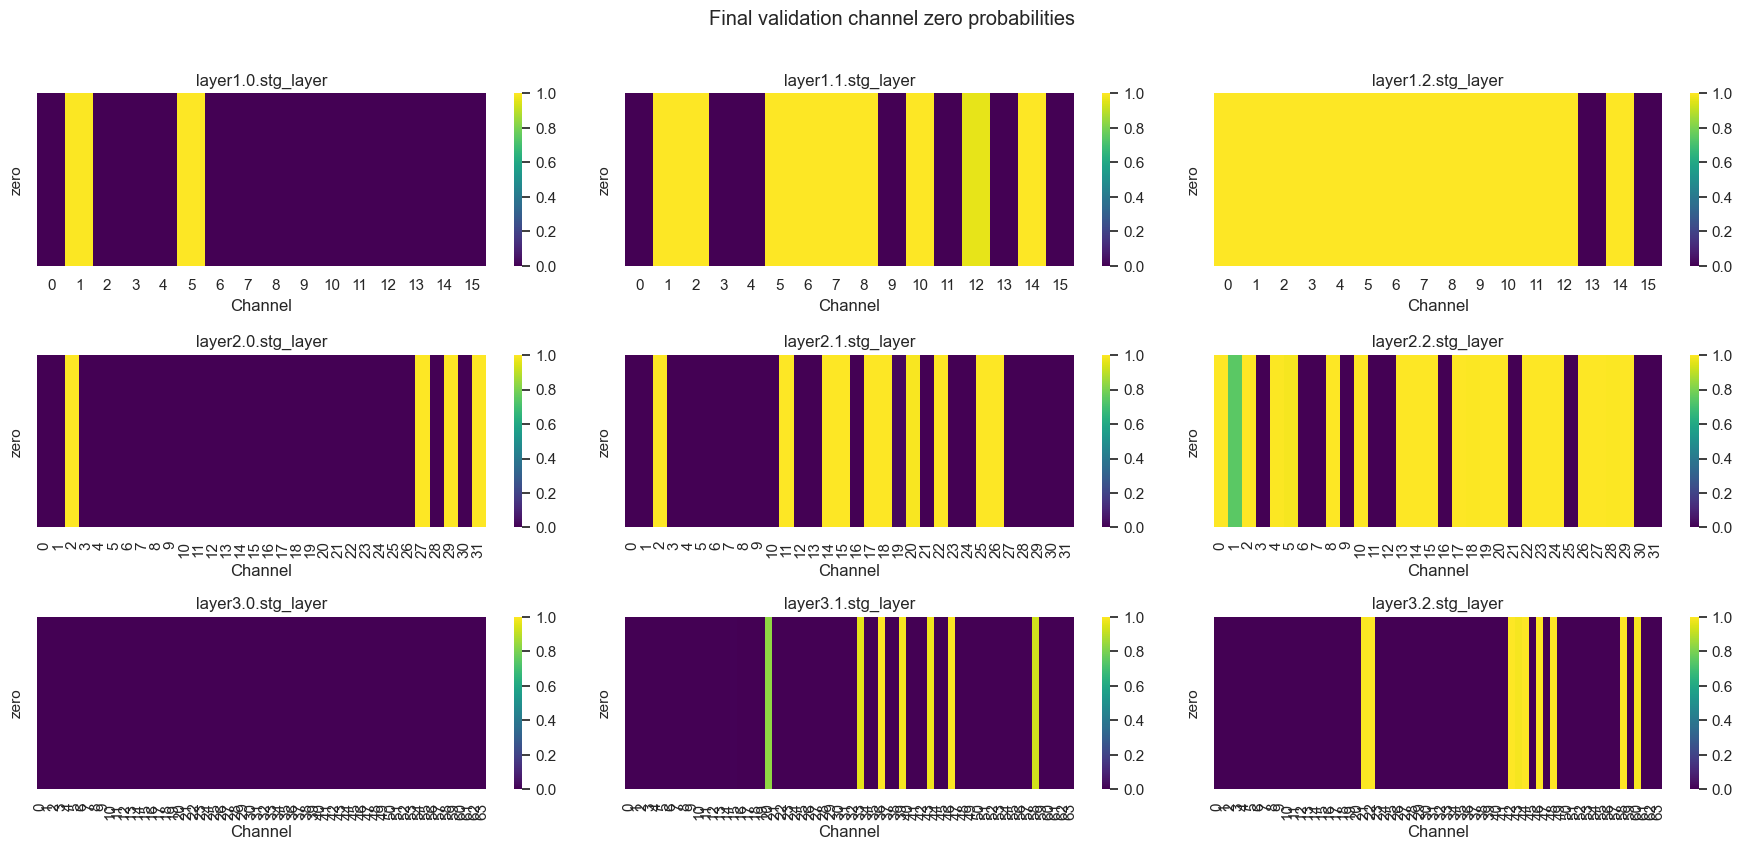

In [14]:
blocks = list(final_zero["block"].drop_duplicates())
n_blocks = len(blocks)
n_cols = 3
n_rows = int(np.ceil(n_blocks / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 2.8 * n_rows), squeeze=False)

for ax, block in zip(axes.ravel(), blocks):
    block_df = final_zero[final_zero["block"] == block].sort_values("channel")
    heatmap_values = block_df["zero_prob"].to_numpy()[None, :]
    sns.heatmap(
        heatmap_values,
        ax=ax,
        cmap="viridis",
        vmin=0,
        vmax=1,
        cbar=True,
        xticklabels=block_df["channel"].to_list(),
        yticklabels=["zero"],
    )
    ax.set_title(block)
    ax.set_xlabel("Channel")
    ax.set_ylabel("")

for ax in axes.ravel()[n_blocks:]:
    ax.axis("off")

plt.suptitle("Final validation channel zero probabilities", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
accuracy_column = "valid_accuracy"
if accuracy_column not in df.columns:
    accuracy_candidates = [column for column in df.columns if column.endswith("_accuracy")]
    raise KeyError(f"Column {accuracy_column!r} was not found. Available accuracy columns: {accuracy_candidates}")

best_accuracy_idx = df[accuracy_column].idxmax()
best_accuracy_epoch = df.loc[best_accuracy_idx]
best_epoch = best_accuracy_epoch["epoch"]

best_epoch_columns = [
    "epoch",
    "lr",
    "train_ce_loss",
    "valid_ce_loss",
    "train_regularization_loss",
    "valid_regularization_loss",
    "train_loss",
    "valid_loss",
    "train_accuracy",
    "valid_accuracy",
    "train_average_estim_prob",
    "valid_average_estim_prob",
    "train_average_zero_prob",
    "valid_average_zero_prob",
    "train_average_real_prob",
    "valid_average_real_prob",
]
best_epoch_columns = [column for column in best_epoch_columns if column in df.columns]
best_epoch_summary = best_accuracy_epoch[best_epoch_columns].to_frame("value")

print(f"Best valid accuracy: {best_accuracy_epoch[accuracy_column]:.6f} at epoch {best_epoch:g}")
display(best_epoch_summary)

if "total_active_channels" in globals():
    best_total_active_channels = total_active_channels[
        np.isclose(total_active_channels["epoch"], best_epoch)
    ].copy()
    if not best_total_active_channels.empty:
        display(best_total_active_channels)

if "active_channels" in globals():
    best_valid_active_by_block = active_channels[
        (active_channels["stage"] == "valid") & np.isclose(active_channels["epoch"], best_epoch)
    ].sort_values("block")
    if not best_valid_active_by_block.empty:
        display(best_valid_active_by_block)

Best valid accuracy: 0.886185 at epoch 103


,value
epoch,103.000000
lr,0.000100
train_ce_loss,0.092938
valid_ce_loss,0.415299
train_regularization_loss,0.681672
valid_regularization_loss,0.681638
train_loss,1.101451
valid_loss,1.423761
train_accuracy,0.969076
valid_accuracy,0.886185


,epoch,stage,expected_active_channels,hard_active_channels,total_channels
204,103.0,train,261.557441,260,336
205,103.0,valid,261.545584,260,336


,epoch,stage,block,expected_active_channels,hard_active_channels,total_channels
3168,103.0,valid,layer1.0.stg_layer,14.010362,14,16
3169,103.0,valid,layer1.1.stg_layer,7.123550,7,16
3170,103.0,valid,layer1.2.stg_layer,2.017979,2,16
3171,103.0,valid,layer2.0.stg_layer,27.998776,28,32
3172,103.0,valid,layer2.1.stg_layer,22.017840,22,32
3173,103.0,valid,layer2.2.stg_layer,11.605450,11,32
3174,103.0,valid,layer3.0.stg_layer,63.975591,64,64
3175,103.0,valid,layer3.1.stg_layer,57.706110,57,64
3176,103.0,valid,layer3.2.stg_layer,55.089927,55,64


In [ ]:
accuracy_column = "valid_accuracy"
if accuracy_column not in df.columns:
    accuracy_candidates = [column for column in df.columns if column.endswith("_accuracy")]
    raise KeyError(f"Column {accuracy_column!r} was not found. Available accuracy columns: {accuracy_candidates}")

best_accuracy_idx = df[accuracy_column].idxmax()
best_accuracy_epoch = df.loc[best_accuracy_idx]
best_epoch = best_accuracy_epoch["epoch"]

best_epoch_columns = [
    "epoch",
    "lr",
    "train_ce_loss",
    "valid_ce_loss",
    "train_regularization_loss",
    "valid_regularization_loss",
    "train_loss",
    "valid_loss",
    "train_accuracy",
    "valid_accuracy",
    "train_average_estim_prob",
    "valid_average_estim_prob",
    "train_average_zero_prob",
    "valid_average_zero_prob",
    "train_average_real_prob",
    "valid_average_real_prob",
]
best_epoch_columns = [column for column in best_epoch_columns if column in df.columns]
best_epoch_summary = best_accuracy_epoch[best_epoch_columns].to_frame("value")

print(f"Best valid accuracy: {best_accuracy_epoch[accuracy_column]:.6f} at epoch {best_epoch:g}")
display(best_epoch_summary)

if "total_active_channels" in globals():
    best_total_active_channels = total_active_channels[
        np.isclose(total_active_channels["epoch"], best_epoch)
    ].copy()
    if not best_total_active_channels.empty:
        display(best_total_active_channels)

if "active_channels" in globals():
    best_valid_active_by_block = active_channels[
        (active_channels["stage"] == "valid") & np.isclose(active_channels["epoch"], best_epoch)
    ].sort_values("block")
    if not best_valid_active_by_block.empty:
        display(best_valid_active_by_block)

Best valid accuracy: 0.886185 at epoch 103


,value
epoch,103.000000
lr,0.000100
train_ce_loss,0.092938
valid_ce_loss,0.415299
train_regularization_loss,0.681672
valid_regularization_loss,0.681638
train_loss,1.101451
valid_loss,1.423761
train_accuracy,0.969076
valid_accuracy,0.886185


,epoch,stage,expected_active_channels,hard_active_channels,total_channels
204,103.0,train,261.557441,260,336
205,103.0,valid,261.545584,260,336


,epoch,stage,block,expected_active_channels,hard_active_channels,total_channels
3168,103.0,valid,layer1.0.stg_layer,14.010362,14,16
3169,103.0,valid,layer1.1.stg_layer,7.123550,7,16
3170,103.0,valid,layer1.2.stg_layer,2.017979,2,16
3171,103.0,valid,layer2.0.stg_layer,27.998776,28,32
3172,103.0,valid,layer2.1.stg_layer,22.017840,22,32
3173,103.0,valid,layer2.2.stg_layer,11.605450,11,32
3174,103.0,valid,layer3.0.stg_layer,63.975591,64,64
3175,103.0,valid,layer3.1.stg_layer,57.706110,57,64
3176,103.0,valid,layer3.2.stg_layer,55.089927,55,64
